## Install Dependencies

uv pip install jupyterlab pandas matplotlib syftbox-enclave syft-rds==0.1.1-dev.2

# Remote Data Science Flow: Department of Health & National Treasury 

This notebook demonstrates a secure data sharing scenario where:

- **Data Owner**: Department of Health (data.governance@health.gov.uk)
- **Data Scientist**: Treasury Analytics (analytics@treasury.gov.uk)

**Dataset**: Department of Health's records including service encounters and prescription events. The data enables Treasury analysts to perform aggregate analysis on healthcare costs and activity without exposing individual-level data.

**Use Case**: Treasury needs to analyze healthcare expenditure patterns, regional cost variations, and prescription spending to inform budget planning and policy decisions.

---
# 0. Both department install SyftBox on their premise & the syft-rds app

Nothing here to show.

---
# 1. Department of Health Uploads the Dataset

The Department of Health data team creates:
- a dataset containing health records for Treasury analysis
- a mock counterpart
- a data card explaining the schema and data collection

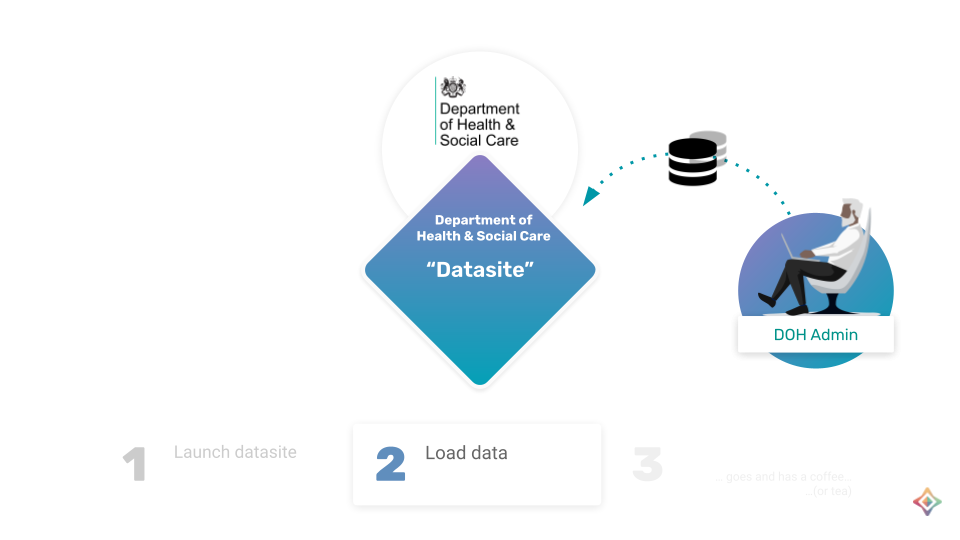

---
# 2. Research from Treasury accesses the dataset

Treasury analytics team can view available datasets and access mock data for development and testing of their analysis code.

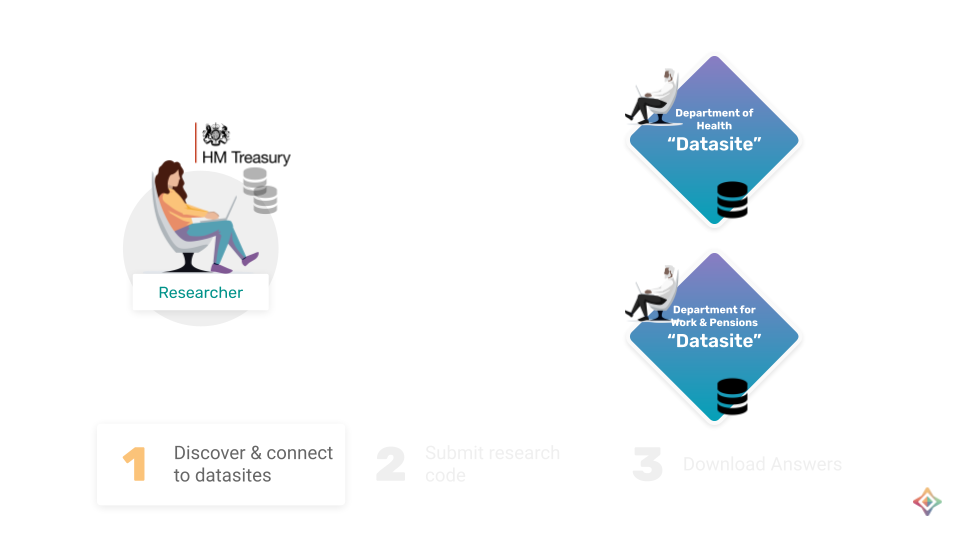

In [1]:
from syft_rds import init_session

In [2]:
ds_client = init_session("<DO_EMAIL")

In [3]:
dataset = ds_client.dataset.get(name="dh_records")
dataset.describe()

uid,aa140da4-1ea6-4686-98c7-745a883e5bf4
created_at,2025-07-08 16:16:17
updated_at,2025-07-08 16:16:17
name,dh_records
readme_path,/Users/rasswanths/SyftBox/datasites/rasswanth@openmined.org/public/datasets/dh_records/dummy_description.txt
mock_path,/Users/rasswanths/SyftBox/datasites/rasswanth@openmined.org/public/datasets/dh_records
private_path,/Users/rasswanths/SyftBox/datasites/rasswanth@openmined.org/private/datasets/dh_records


### Inspect the data and inform their analysis



In [4]:
#TODO: will enable mock part soon
# import pandas as pd

# mock_csv_path = dataset.get_mock_path() / "dh_records.csv"
# df_mock = pd.read_csv(mock_csv_path, parse_dates=['event_date'])

# print(f"Record types: {df_mock['record_type'].unique()}")
# print(f"Regions: {df_mock['region_code'].unique()}")

# df_mock.head(3)
    

### Propose analysis

In [5]:
from pathlib import Path

code_path = Path(".") / "code"
code_path.mkdir(exist_ok=True)

code_file_name  = "dh_analysis.py"
code_file_path = code_path / code_file_name

In [ ]:
data_file_name = input("Enter File name of the private data")

In [6]:
%%writefile {code_file_path}

import os
import pandas as pd
import json

DATA_DIR = os.environ["DATA_DIR"]
OUTPUT_DIR = os.environ["OUTPUT_DIR"]

print("Treasury Analytics: Department of Health Records Analysis")
print("=" * 55)

# Load the DH raw records dataset
csv_path = os.path.join(DATA_DIR, data_file_name)
df = pd.read_csv(csv_path, parse_dates=['event_date'])

print(f"Loaded {len(df)} health records for analysis")
print(f"Date range: {df['event_date'].min()} to {df['event_date'].max()}")

# Analysis 1: Healthcare costs by region
print("\n1. Healthcare Costs by NHS Region:")
encounter_costs = df[df['record_type'] == 'encounter'].groupby('region_code').agg({
    'cost_gbp': ['sum', 'mean', 'count']
}).round(2)
encounter_costs.columns = ['Total_Cost_GBP', 'Avg_Cost_GBP', 'Total_Encounters']
print(encounter_costs)

# Analysis 2: Prescription costs by BNF chapter
print("\n2. Prescription Costs by Drug Category:")
prescription_costs = df[df['record_type'] == 'prescription'].groupby('bnf_chapter').agg({
    'prescription_cost_gbp': ['sum', 'mean', 'count'],
    'item_count': 'sum'
}).round(2)
prescription_costs.columns = ['Total_Prescription_Cost_GBP', 'Avg_Prescription_Cost_GBP', 'Total_Prescriptions', 'Total_Items']
print(prescription_costs)

# Analysis 3: Activity by encounter type
print("\n3. Healthcare Activity by Service Type:")
activity_summary = df[df['record_type'] == 'encounter'].groupby('encounter_type').agg({
    'record_id': 'count',
    'cost_gbp': 'sum',
    'length_of_stay_days': 'mean'
}).round(2)
activity_summary.columns = ['Total_Encounters', 'Total_Cost_GBP', 'Avg_Length_of_Stay']
print(activity_summary)

# Save aggregate results for Treasury reporting
results = {
    "total_healthcare_cost": float(df[df['record_type'] == 'encounter']['cost_gbp'].sum()),
    "total_prescription_cost": float(df[df['record_type'] == 'prescription']['prescription_cost_gbp'].sum()),
    "total_encounters": int(df[df['record_type'] == 'encounter'].shape[0]),
    "total_prescriptions": int(df[df['record_type'] == 'prescription'].shape[0]),
    "cost_by_region": encounter_costs.to_dict(),
    "prescription_costs_by_category": prescription_costs.to_dict(),
    "activity_by_service_type": activity_summary.to_dict()
}

# Write summary report
with open(os.path.join(OUTPUT_DIR, "treasury_health_analysis_summary.json"), "w") as f:
    json.dump(results, f, indent=2)

# Write detailed CSV reports
encounter_costs.to_csv(os.path.join(OUTPUT_DIR, "costs_by_region.csv"))
prescription_costs.to_csv(os.path.join(OUTPUT_DIR, "prescription_costs_by_category.csv"))
activity_summary.to_csv(os.path.join(OUTPUT_DIR, "activity_by_service_type.csv"))

print(f"\n✅ Analysis complete. Total healthcare expenditure: £{results['total_healthcare_cost']:,.2f}")
print(f"✅ Total prescription expenditure: £{results['total_prescription_cost']:,.2f}")


Overwriting code/dh_analysis.py


### Test the analysis code against mock data

Before submitting the code for review, Treasury can test their analysis against the Department of Health mock data to ensure it works correctly.


In [7]:
# Mock Path Testing will be enabled soon
# # Quick test against mock data
# import subprocess, tempfile, os
# from pathlib import Path

# with tempfile.TemporaryDirectory() as temp_dir:
#     env = os.environ.copy()
#     env.update({'DATA_DIR': str(dataset.get_mock_path()), 'OUTPUT_DIR': temp_dir})
    
#     result = subprocess.run(["python", str(code_file_path)], env=env, capture_output=True, text=True)
#     print(result.stdout)

---
# 3. Treasury submits analysis code for review

Treasury analyst submits their healthcare expenditure analysis code to be reviewed by Department of Health data governance team before execution on private data.

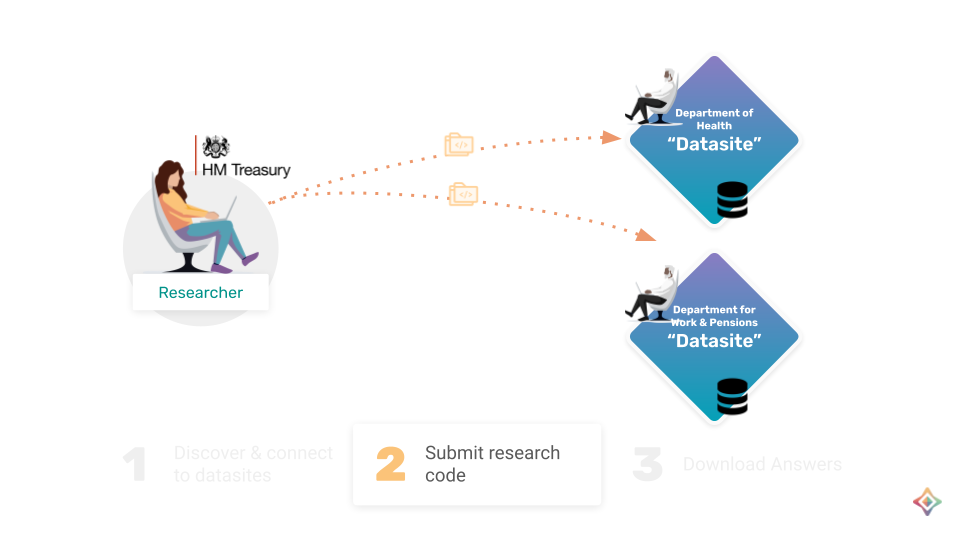

In [8]:
from uuid import uuid4

# Generate 
RANDOM_ID = str(uuid4())[0:8]
JOB_NAME = f"Test Job - {RANDOM_ID}"

print("Job Name:", JOB_NAME)

Job Name: Test Job - abd62c31


In [9]:
ENCLAVE = "enclave-ndl-gov-data@openmined.org"

job = ds_client.jobs.submit(
            name=JOB_NAME,
            description="NDL Gov Data Experiment",
            user_code_path=code_path,
            dataset_name=dataset.name,
            entrypoint = code_file_name,
            enclave = ENCLAVE
        )
job.describe()

uid,60b22fec-2460-4ddf-a488-3d9ebb70fe6e
created_by,rasswanth@openmined.org
created_at,2025-07-08 16:40:48
updated_at,2025-07-08 16:40:48
name,Test Job - abd62c31
description,NDL Gov Data Experiment
status,pending_code_review
error,no_error
error_message,None
output_path,/Users/rasswanths/SyftBox/datasites/rasswanth@openmined.org/app_data/RDS/user_files/rasswanth@openmined.org/Job/60b22fec-2460-4ddf-a488-3d9ebb70fe6e
dataset_name,dh_records


---
# 4. Department of Health reviews the code

DH data governance team reviews Treasury's analysis code to ensure it meets privacy and security requirements before allowing execution on sensitive health data.

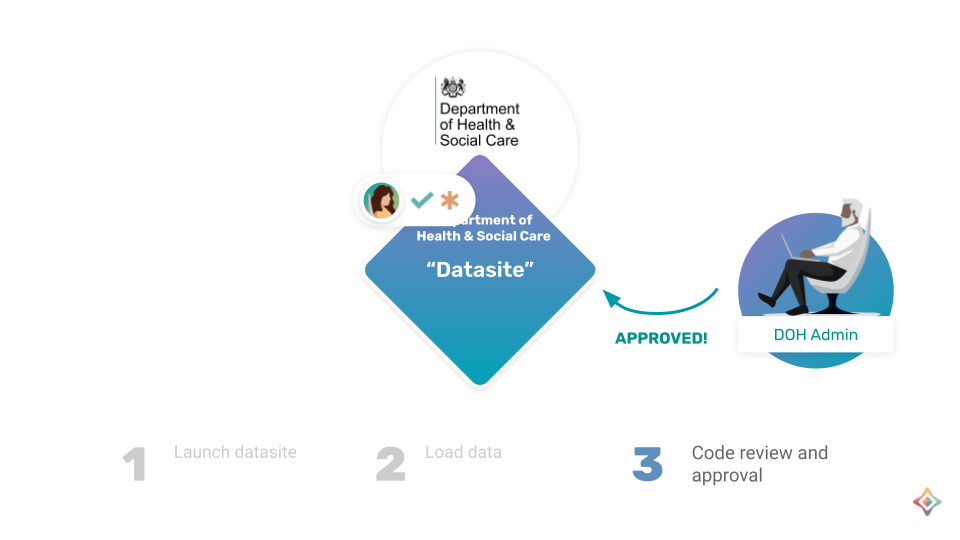

In [11]:
# Wait till the JOB is approved
ds_client.jobs.get(name=JOB_NAME).describe()

uid,60b22fec-2460-4ddf-a488-3d9ebb70fe6e
created_by,rasswanth@openmined.org
created_at,2025-07-08 16:40:48
updated_at,2025-07-08 16:41:25
name,Test Job - abd62c31
description,NDL Gov Data Experiment
status,approved
error,no_error
error_message,None
output_path,/Users/rasswanths/SyftBox/datasites/rasswanth@openmined.org/app_data/RDS/user_files/rasswanth@openmined.org/Job/60b22fec-2460-4ddf-a488-3d9ebb70fe6e
dataset_name,dh_records


## Enclave Client

In [12]:
from syftbox_enclave import connect

In [13]:
enclave_client = connect(ENCLAVE)

In [14]:
PROJECT_NAME = f"Test Project - {RANDOM_ID}"

print("Project Name:", PROJECT_NAME)

Project Name: Test Project - abd62c31


In [15]:
proj_res = enclave_client.create_project(
                   project_name = PROJECT_NAME,
                   datasets = [dataset],
                   output_owners = [ds_client.email],
                   code_path = code_path,
                   entrypoint = code_file_name,
            )

2025-07-08 22:11:32.788 | INFO     | syftbox_enclave.client:create_project:79 - Project Test Project - abd62c31 created in enclave app path /Users/rasswanths/SyftBox/datasites/enclave-ndl-gov-data@openmined.org/app_data/enclave.


---
# 5. Treasury accesses approved results

After DH approval and execution, Treasury can access the aggregated analysis results for their budget planning and policy work.

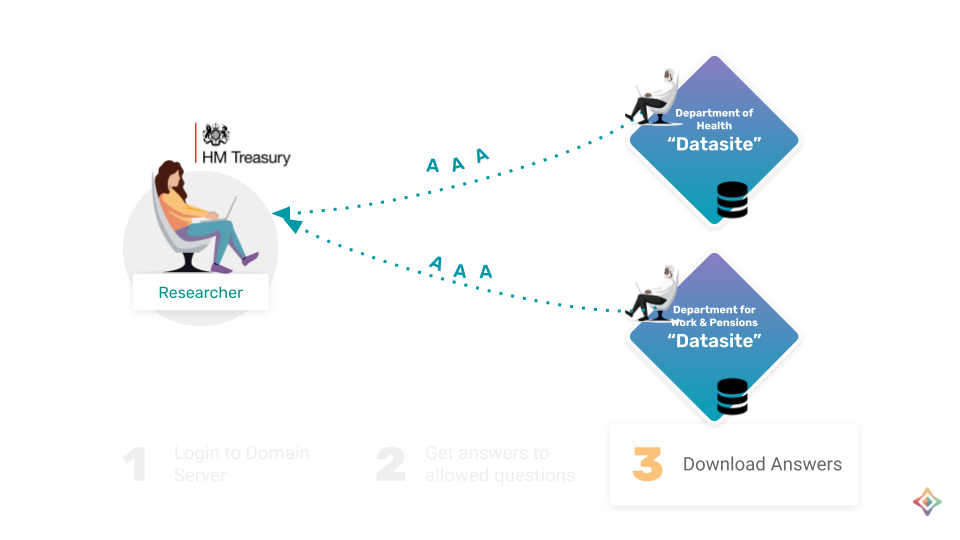

In [16]:
# Wait until the project is ready
proj_res_path = proj_res.output(block=True)

2025-07-08 22:11:39.769 | INFO     | syftbox_enclave.client:output:104 - Waiting for output for project Test Project - abd62c31...


.......

2025-07-08 22:11:53.806 | INFO     | syftbox_enclave.client:output:109 - Output available for project Test Project - abd62c31 ✅
 Directory: /Users/rasswanths/SyftBox/datasites/enclave-ndl-gov-data@openmined.org/app_data/enclave/jobs/outputs/Test Project - abd62c31.


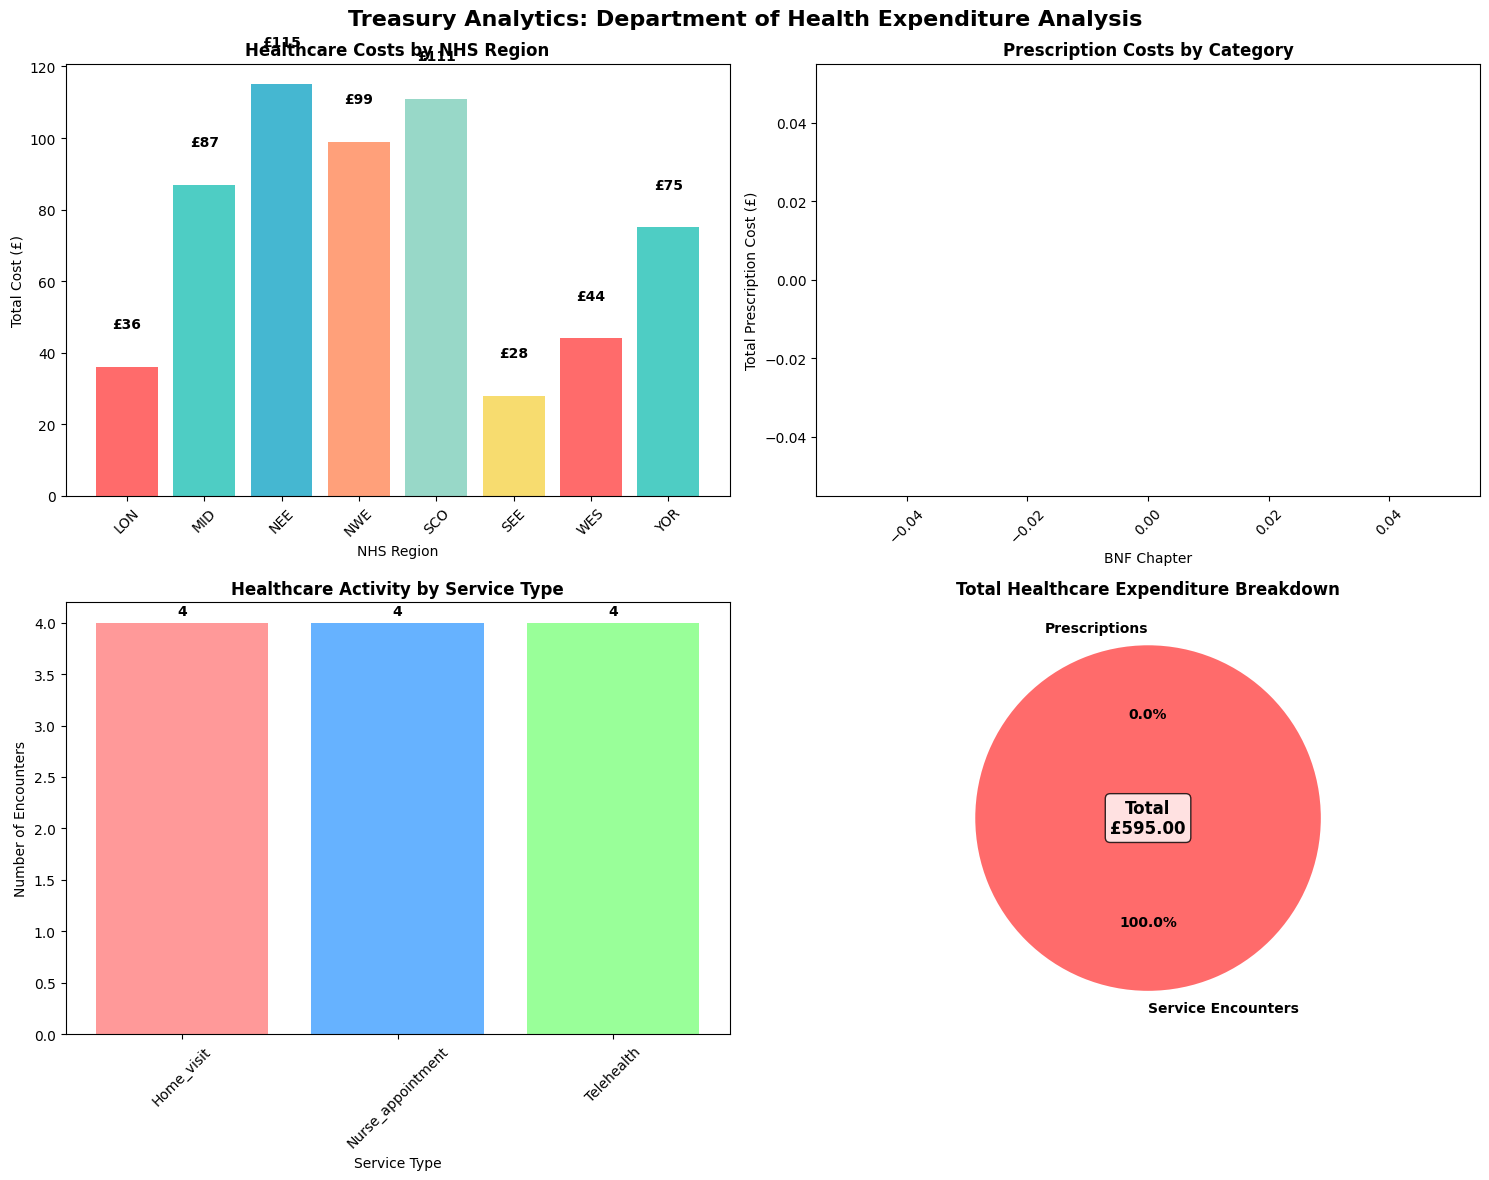

In [18]:
import matplotlib.pyplot as plt
import json
import pandas as pd

# Set up the plotting style
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Treasury Analytics: Department of Health Expenditure Analysis', fontsize=16, fontweight='bold')


results_json_path = proj_res_path / 'treasury_health_analysis_summary.json'
# Load the results
if results_json.exists():
    # Parse the JSON data
    f = open(results_json_path, 'r')  # Manually open the file
    results_json = json.load(f) 
    
    # Chart 1: Healthcare Costs by NHS Region
    region_data = pd.DataFrame(results_json['cost_by_region'])
    ax1 = axes[0, 0]
    bars1 = ax1.bar(region_data.index, region_data['Total_Cost_GBP'], 
                    color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F'])
    ax1.set_title('Healthcare Costs by NHS Region', fontweight='bold')
    ax1.set_xlabel('NHS Region')
    ax1.set_ylabel('Total Cost (£)')
    ax1.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 10,
                f'£{height:,.0f}', ha='center', va='bottom', fontweight='bold')
    
    # Chart 2: Prescription Costs by Category
    prescription_data = pd.DataFrame(results_json['prescription_costs_by_category'])
    ax2 = axes[0, 1]
    bars2 = ax2.bar(prescription_data.index, prescription_data['Total_Prescription_Cost_GBP'],
                    color=['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6'])
    ax2.set_title('Prescription Costs by Category', fontweight='bold')
    ax2.set_xlabel('BNF Chapter')
    ax2.set_ylabel('Total Prescription Cost (£)')
    ax2.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'£{height:.2f}', ha='center', va='bottom', fontweight='bold')
    
    # Chart 3: Activity by Service Type
    activity_data = pd.DataFrame(results_json['activity_by_service_type'])
    ax3 = axes[1, 0]
    bars3 = ax3.bar(activity_data.index, activity_data['Total_Encounters'],
                    color=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC'])
    ax3.set_title('Healthcare Activity by Service Type', fontweight='bold')
    ax3.set_xlabel('Service Type')
    ax3.set_ylabel('Number of Encounters')
    ax3.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar in bars3:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')
    
    # Chart 4: Cost Summary Pie Chart
    ax4 = axes[1, 1]
    total_healthcare = results_json['total_healthcare_cost']
    total_prescription = results_json['total_prescription_cost']
    
    costs = [total_healthcare, total_prescription]
    labels = ['Service Encounters', 'Prescriptions']
    colors = ['#FF6B6B', '#4ECDC4']
    
    wedges, texts, autotexts = ax4.pie(costs, labels=labels, colors=colors, autopct='%1.1f%%',
                                       startangle=90, textprops={'fontweight': 'bold'})
    ax4.set_title('Total Healthcare Expenditure Breakdown', fontweight='bold')
    
    # Add total cost in center
    total_cost = total_healthcare + total_prescription
    ax4.text(0, 0, f'Total\n£{total_cost:,.2f}', ha='center', va='center', 
             fontsize=12, fontweight='bold', 
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    plt.tight_layout()
    plt.show()
    
else:
    print("No analysis results available to visualize.")
